# 12 · Capstone: Predicting Concrete Compressive Strength

[← Course home](../README.md)

An end-to-end project on **real laboratory data**: 1030 concrete mixes from Yeh (1998), each described by its
ingredients (kg per m³ of concrete) and its age at testing (days), with the measured **compressive strength** (MPa).
We use everything from the course — framing, cleaning, leakage-safe splitting, EDA, feature engineering in pipelines,
model comparison, tuning, honest evaluation, interpretation — and add something new: **physics**.

**What you will learn**

- How to frame a regression problem so that the metric means something to an engineer
- Auditing raw data with physical sanity checks (mass balance, impossible values, duplicates, replicates)
- Why rows of the *same mix* tested at different ages leak across a random split — and how `GroupKFold` fixes it
- Physics-informed features (water–cement ratio, water–binder ratio, log age) inside a `Pipeline` via `FunctionTransformer`
- Fitting **Abrams' law** with `scipy.optimize.curve_fit` as a physical baseline model
- Comparing, tuning and evaluating models once on a held-out test set, with a (cluster-)bootstrap confidence interval
- Checking that the model's partial dependences agree with physics, saving it with `joblib`, and writing a model card

In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import sklearn
from scipy.optimize import curve_fit
from scipy.stats import loguniform, randint, uniform
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, StandardScaler

from mlaz import PALETTE, load_concrete, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
T0 = time.time()

## 1 · Problem framing

**Context.** Concrete is cement + water + aggregates (sand = *fine*, gravel = *coarse*), often with
*supplementary cementitious materials* (SCMs: blast-furnace **slag**, fly **ash**) and chemical admixtures
(**superplasticizer**). Cement reacts with water (**hydration**) to form calcium-silicate-hydrate gel that binds the
aggregates. Strength is specified at **28 days**; the standard test crushes cylinders or cubes in a press.
Getting a new mix to a target strength normally takes **trial batches and 28 days of waiting** — a model that predicts
strength from the recipe can screen designs before pouring anything.

Two classical engineering laws give us expectations:

- **Abrams' law (1918):** at a given age, strength falls exponentially with the **water–cement ratio** $w/c$:
  $$f_c = \frac{A}{B^{\,w/c}}$$
  Extra water beyond what hydration needs leaves capillary pores → weaker paste.
- **Strength gain with age:** fast at first, then slowing, roughly linear in $\log(\text{age})$; ACI 209 uses
  $f_c(t) = f_{c,28}\,\dfrac{t}{a + b\,t}$ (for ordinary cement $a\approx4$, $b\approx0.85$).

**ML task.** Supervised regression: predict `strength` (MPa) from 7 mix components + `age`.

**Metric.** RMSE in MPa — same unit as the target, penalises large misses (an over-predicted strength is a safety
issue). We also report MAE and $R^2$.

**What error is acceptable?** Strength classes (e.g. C25/30, C30/37, C35/45) are ~5 MPa apart, and Eurocode 2 sets the
mean target strength 8 MPa above the characteristic value to cover production scatter. Replicate cylinders of the
same batch differ by a few MPa. So an RMSE of **≈ 4–5 MPa** is useful for *screening* mix designs, but no model replaces
the compliance test. We will measure the replicate noise in this very dataset below.

**Baseline.** Predict the training mean (`DummyRegressor`) — any model must beat that — plus a *physics* baseline
built on Abrams' law.

## 2 · Load the raw data and audit it

In [2]:
raw = load_concrete()
print(raw.shape)
print(raw.dtypes.value_counts().to_dict())
raw.head()

(1030, 9)
{dtype('float64'): 8, dtype('int64'): 1}


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
raw.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.2,104.5,102.0,192.4,272.9,350.0,540.0
slag,1030.0,73.9,86.3,0.0,0.0,22.0,143.0,359.4
ash,1030.0,54.2,64.0,0.0,0.0,0.0,118.3,200.1
water,1030.0,181.6,21.4,121.8,164.9,185.0,192.0,247.0
superplastic,1030.0,6.2,6.0,0.0,0.0,6.4,10.2,32.2
coarseagg,1030.0,972.9,77.8,801.0,932.0,968.0,1029.4,1145.0
fineagg,1030.0,773.6,80.2,594.0,731.0,779.5,824.0,992.6
age,1030.0,45.7,63.2,1.0,7.0,28.0,56.0,365.0
strength,1030.0,35.8,16.7,2.3,23.7,34.4,46.1,82.6


**Checks:**

1. Missing values and types.
2. **Physically impossible values**: negative amounts, zero cement (no hydration), zero/negative age or strength.
3. **Mass balance**: the components of 1 m³ of concrete should add up to its density, ≈ 2200–2500 kg/m³ for
   normal-weight concrete (air voids make up the rest of the volume).
4. **Duplicates**: identical rows, and the same mix tested at the same age with different results (replicates).

In [4]:
components = ["cement", "slag", "ash", "water", "superplastic", "coarseagg", "fineagg"]
audit = {
    "missing values": int(raw.isna().sum().sum()),
    "negative amounts": int((raw[components] < 0).sum().sum()),
    "zero cement": int((raw["cement"] <= 0).sum()),
    "age <= 0": int((raw["age"] <= 0).sum()),
    "strength <= 0": int((raw["strength"] <= 0).sum()),
    "water/cement > 2 or < 0.2": int(((raw.water / raw.cement > 2) | (raw.water / raw.cement < 0.2)).sum()),
    "exact duplicate rows": int(raw.duplicated().sum()),
}
total_mass = raw[components].sum(axis=1)
audit["total mass < 2200 kg/m³"] = int((total_mass < 2200).sum())
audit["total mass > 2500 kg/m³"] = int((total_mass > 2500).sum())
print(f"total mass: min {total_mass.min():.0f}, median {total_mass.median():.0f}, max {total_mass.max():.0f} kg/m³")
pd.Series(audit, name="count")

total mass: min 2195, median 2349, max 2551 kg/m³


missing values                0
negative amounts              0
zero cement                   0
age <= 0                      0
strength <= 0                 0
water/cement > 2 or < 0.2     0
exact duplicate rows         25
total mass < 2200 kg/m³       3
total mass > 2500 kg/m³       1
Name: count, dtype: int64

No missing or impossible values. Total masses of 2195–2551 kg/m³ are plausible: only 3 mixes fall (just) below
2200 kg/m³ and one lies above 2500 kg/m³ — within the tolerance of batch records, so nothing to remove. The **25 exact duplicate rows** are the only real issue: same recipe, same age, same
strength to 0.01 MPa — almost certainly copy-paste artefacts of assembling the dataset from several sources.
We drop them: they would otherwise over-weight a few mixes, and (worse) could sit on both sides of a train/test split.

In [5]:
df = raw.drop_duplicates().reset_index(drop=True)
df["mix_id"] = df.groupby(components, sort=False).ngroup()
sizes = df.groupby("mix_id").size()
print(f"{len(df)} rows after dropping duplicates, {df.mix_id.nunique()} distinct mixes")
print("rows per mix:", sizes.value_counts().sort_index().to_dict())

rep = df[df.duplicated(components + ["age"], keep=False)]
rep_stats = (rep.groupby(components + ["age"])["strength"]
             .agg(n="count", mean="mean", sd="std", lo="min", hi="max").reset_index())
rep_stats["range"] = rep_stats.hi - rep_stats.lo
print(f"{len(rep_stats)} mix/age combinations have replicate tests (same recipe, same age):")
print(rep_stats[["cement", "slag", "ash", "age", "n", "mean", "sd", "range"]].round(2).to_string(index=False))
suspicious = rep_stats["range"] > 20
noise_sd = np.sqrt((rep_stats.loc[~suspicious, "sd"] ** 2).mean())
print(f"\nmedian replicate SD = {rep_stats.sd.median():.2f} MPa; pooled SD without the suspicious pair = {noise_sd:.2f} MPa")

1005 rows after dropping duplicates, 427 distinct mixes
rows per mix: {1: 246, 2: 42, 3: 7, 4: 37, 5: 77, 6: 12, 7: 3, 8: 2, 12: 1}
9 mix/age combinations have replicate tests (same recipe, same age):
 cement  slag   ash  age  n  mean    sd  range
  359.0  19.0 141.0    3  2 24.38  1.05   1.48
  359.0  19.0 141.0    7  2 37.18  2.02   2.86
  359.0  19.0 141.0   28  2 61.22  2.44   3.45
  359.0  19.0 141.0   56  2 67.76  1.39   1.97
  362.6 189.0   0.0    7  2 39.40 23.33  33.00
  446.0  24.0  79.0    3  3 27.91  6.51  12.01
  446.0  24.0  79.0    7  3 43.11  7.73  13.99
  446.0  24.0  79.0   28  3 50.82  6.31  12.61
  446.0  24.0  79.0   56  3 57.49  3.14   5.82

median replicate SD = 3.14 MPa; pooled SD without the suspicious pair = 4.54 MPa


Two findings that shape everything that follows:

- Only 246 of the 427 mixes were tested at a single age; the others were tested at up to 12 ages. **Rows are not
  independent** — they come in groups (mixes).
- Replicate tests (same mix, same age) typically differ by a few MPa (pooled SD ≈ 4.5 MPa). That is **irreducible
  noise**: no model can be expected to get much below it.
- One pair is **suspicious**: the same recipe at 7 days measured 55.9 and 22.9 MPa. One of the two is probably a
  transcription error, but we cannot tell which, so we keep both — and remember that such rows inflate every model's
  error a little. (Deleting "inconvenient" points is how optimistic papers are made.)

## 3 · Split first — by mix

If the same mix appears in training at 28 days and in the test set at 56 days, the model can "recognise" the recipe
and interpolate along age. That is not the task we care about: we want to predict strength for a **new recipe**.
A random row-wise split therefore gives **optimistic** scores. We split by `mix_id` so that every mix is entirely in
train *or* in test, and use `GroupKFold` for cross-validation on the training part.

In [6]:
X_all = df[components + ["age"]].astype(float)
y_all = df["strength"]
groups_all = df["mix_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X_all, y_all, groups_all))
X_train, X_test = X_all.iloc[tr_idx], X_all.iloc[te_idx]
y_train, y_test = y_all.iloc[tr_idx], y_all.iloc[te_idx]
g_train, g_test = groups_all.iloc[tr_idx], groups_all.iloc[te_idx]
print(f"train: {len(X_train)} rows / {g_train.nunique()} mixes   test: {len(X_test)} rows / {g_test.nunique()} mixes")
print("mixes in both:", len(set(g_train) & set(g_test)))

cv_group = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_random = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

train: 800 rows / 341 mixes   test: 205 rows / 86 mixes
mixes in both: 0


**How big is the leak?** Same model, same training data, two CV schemes:

In [7]:
probe = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
leak = {}
for name, cv in [("KFold (rows, leaky)", cv_random), ("GroupKFold (mixes)", cv_group)]:
    grp = g_train if isinstance(cv, GroupKFold) else None
    s = cross_validate(probe, X_train, y_train, groups=grp, cv=cv, scoring="neg_root_mean_squared_error")
    leak[name] = -s["test_score"].mean()
pd.Series(leak, name="CV RMSE (MPa)").round(2)

KFold (rows, leaky)    4.50
GroupKFold (mixes)     6.35
Name: CV RMSE (MPa), dtype: float64

The random split under-states the error by almost 2 MPa (≈ 30 %): the model gets credit for recognising recipes it has
already seen at other ages. From here on, **all** CV uses `GroupKFold`.

## 4 · Exploratory data analysis (training set only)

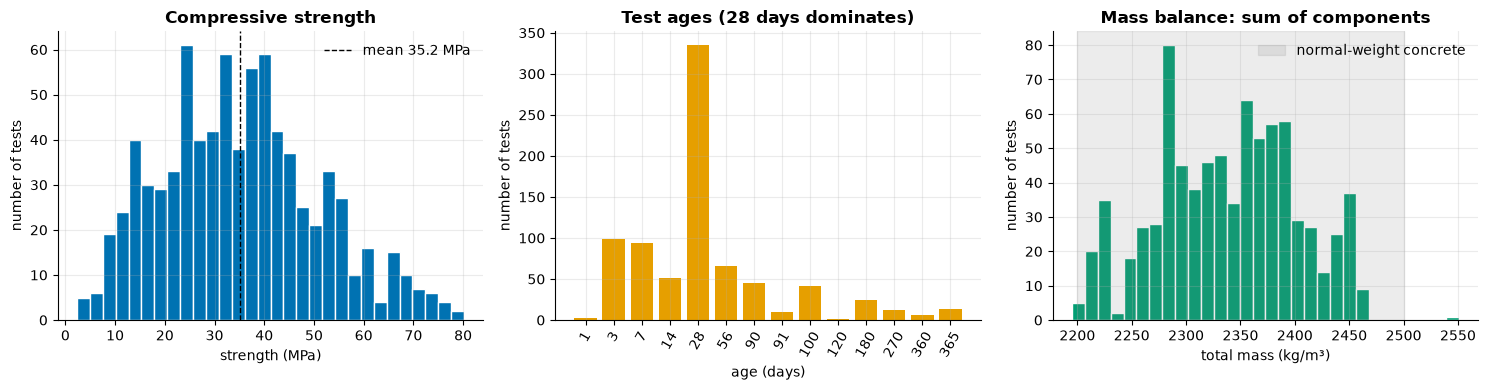

In [8]:
tr = X_train.assign(strength=y_train)
tr["w_c"] = tr.water / tr.cement
tr["binder"] = tr.cement + tr.slag + tr.ash
tr["w_b"] = tr.water / tr.binder

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(tr.strength, bins=30, color=PALETTE[0], edgecolor="white")
axes[0].axvline(tr.strength.mean(), color="k", ls="--", lw=1, label=f"mean {tr.strength.mean():.1f} MPa")
axes[0].set(title="Compressive strength", xlabel="strength (MPa)", ylabel="number of tests")
axes[0].legend()
age_counts = tr.age.value_counts().sort_index()
axes[1].bar(age_counts.index.astype(int).astype(str), age_counts.values, color=PALETTE[1])
axes[1].set(title="Test ages (28 days dominates)", xlabel="age (days)", ylabel="number of tests")
axes[1].tick_params(axis="x", rotation=60)
mass = tr[components].sum(axis=1)
axes[2].hist(mass, bins=30, color=PALETTE[2], edgecolor="white")
axes[2].axvspan(2200, 2500, color="grey", alpha=0.15, label="normal-weight concrete")
axes[2].set(title="Mass balance: sum of components", xlabel="total mass (kg/m³)", ylabel="number of tests")
axes[2].legend(loc="upper right")
fig.tight_layout()
savefig("eda_distributions")
plt.show()

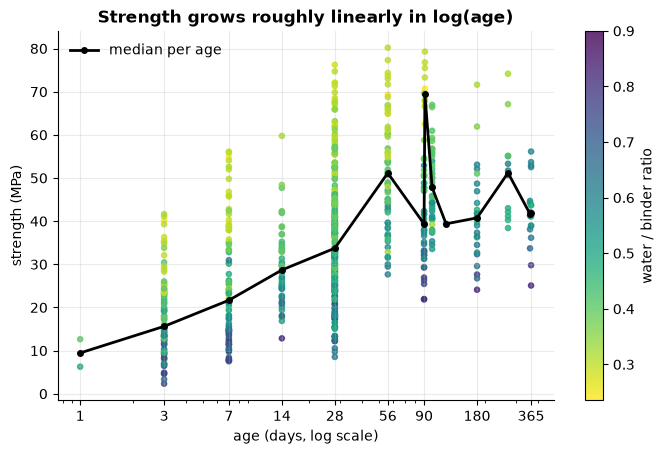

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sc = ax.scatter(tr.age, tr.strength, c=tr.w_b, cmap="viridis_r", s=14, alpha=0.8)
med = tr.groupby("age").strength.median()
ax.plot(med.index, med.values, "o-", color="k", lw=2, ms=4, label="median per age")
ax.set_xscale("log")
ax.set_xticks([1, 3, 7, 14, 28, 56, 90, 180, 365], ["1", "3", "7", "14", "28", "56", "90", "180", "365"])
ax.set(title="Strength grows roughly linearly in log(age)", xlabel="age (days, log scale)", ylabel="strength (MPa)")
fig.colorbar(sc, ax=ax, label="water / binder ratio")
ax.legend(loc="upper left")
savefig("strength_vs_age")
plt.show()

Up to 56 days the median climbs almost linearly on the log-age axis (it roughly doubles between 3 and 28 days).
Beyond that it zig-zags — not because concrete gets weaker, but because **different mixes were tested at different
ages**: the 91-day tests are almost all low-w/b, high-strength mixes. Such composition confounding is exactly why we
need a multivariate model rather than per-age averages. At any age, low **water–binder** mixes (yellow) are strongest. Correlations with strength in the training data:

In [10]:
tr[components + ["age", "w_c", "w_b"]].corrwith(tr.strength, method="spearman").sort_values().round(2).to_frame("Spearman ρ with strength")

,Spearman ρ with strength
w_b,-0.58
w_c,-0.48
water,-0.26
fineagg,-0.22
coarseagg,-0.13
ash,0.00
slag,0.13
superplastic,0.31
cement,0.44
age,0.61


`w_b` has the strongest (negative) rank correlation of all — stronger than any raw ingredient. That is the
case for physics-informed features.

## 5 · Physics-informed feature engineering

We derive, from the raw recipe:

| Feature | Formula | Physical meaning |
|---|---|---|
| `w_c` | water / cement | Abrams' ratio |
| `binder` | cement + slag + ash | total reactive material |
| `w_b` | water / binder | Abrams' ratio counting SCMs (they hydrate too, more slowly) |
| `log_age` | ln(age) | strength gain ~ log(time) |
| `agg_binder` | (coarse + fine) / binder | paste content (lean vs rich mix) |
| `sp_binder` | superplasticizer / binder | admixture dosage (allows low water) |
| `scm_frac` | (slag + ash) / binder | cement replacement level |

Implemented as a plain function wrapped in a `FunctionTransformer`, so it runs **inside** the pipeline (on each CV
fold, on the test set, and at prediction time) — no chance of computing features differently in production.

In [11]:
# The function lives in mlaz/concrete.py (not in the notebook) so the saved model can be
# loaded by any Python process: joblib stores functions *by reference*, not by value.
import inspect

from mlaz.concrete import add_physics_features

print(inspect.getsource(add_physics_features))
physics = FunctionTransformer(add_physics_features, validate=False)
physics.fit_transform(X_train).iloc[:3].round(3)

def add_physics_features(X):
    """Append physics-informed ratios to the raw mix design (all inputs in kg/m³, age in days)."""
    X = pd.DataFrame(X, columns=CONCRETE_INPUTS).copy()
    binder = X["cement"] + X["slag"] + X["ash"]
    X["w_c"] = X["water"] / X["cement"]
    X["binder"] = binder
    X["w_b"] = X["water"] / binder
    X["log_age"] = np.log(X["age"])
    X["agg_binder"] = (X["coarseagg"] + X["fineagg"]) / binder
    X["sp_binder"] = X["superplastic"] / binder
    X["scm_frac"] = (X["slag"] + X["ash"]) / binder
    return X



,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,w_c,binder,w_b,log_age,agg_binder,sp_binder,scm_frac
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,0.300,540.0,0.30,3.332,3.206,0.005,0.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,0.686,475.0,0.48,5.598,3.213,0.000,0.3
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,0.686,475.0,0.48,5.900,3.213,0.000,0.3


## 6 · A physics baseline: Abrams' law with `curve_fit`

First the classic form on the 28-day tests, $f_{28} = A / B^{x}$ with $x = w/c$ or $w/b$, fitted by non-linear least
squares:

In [12]:
def abrams(x, A, B):
    return A / B**x


m28 = tr.age == 28
fits = {}
for ratio in ["w_c", "w_b"]:
    p, cov = curve_fit(abrams, tr.loc[m28, ratio], tr.loc[m28, "strength"], p0=[100, 5])
    resid = tr.loc[m28, "strength"] - abrams(tr.loc[m28, ratio], *p)
    fits[ratio] = {"A (MPa)": p[0], "B": p[1], "A std err": np.sqrt(cov[0, 0]), "B std err": np.sqrt(cov[1, 1]),
                   "RMSE (MPa)": np.sqrt((resid**2).mean()),
                   "R²": 1 - (resid**2).sum() / ((tr.loc[m28, "strength"] - tr.loc[m28, "strength"].mean()) ** 2).sum()}
fits = pd.DataFrame(fits).T
print(f"{m28.sum()} training tests at 28 days")
fits.round(3)

335 training tests at 28 days


,A (MPa),B,A std err,B std err,RMSE (MPa),R²
w_c,70.932,2.387,2.778,0.131,10.077,0.463
w_b,130.706,17.855,7.052,2.336,8.412,0.626


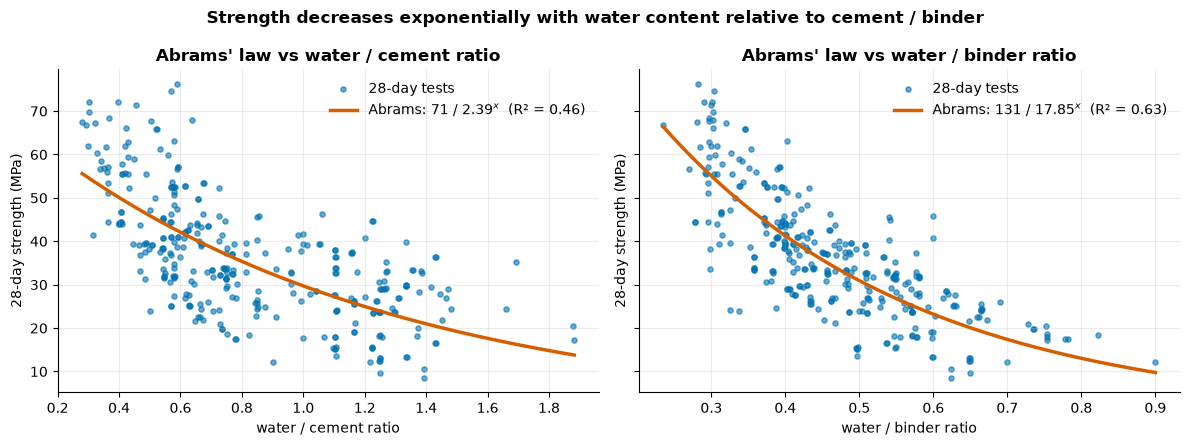

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, ratio, label in [(axes[0], "w_c", "water / cement ratio"), (axes[1], "w_b", "water / binder ratio")]:
    sub = tr[m28]
    ax.scatter(sub[ratio], sub.strength, s=14, alpha=0.6, color=PALETTE[0], label="28-day tests")
    xs = np.linspace(sub[ratio].min(), sub[ratio].max(), 200)
    A, B = fits.loc[ratio, ["A (MPa)", "B"]]
    ax.plot(xs, abrams(xs, A, B), color=PALETTE[3], lw=2.5,
            label=f"Abrams: {A:.0f} / {B:.2f}$^{{x}}$  (R² = {fits.loc[ratio, 'R²']:.2f})")
    ax.set(title=f"Abrams' law vs {label}", xlabel=label, ylabel="28-day strength (MPa)")
    ax.legend()
fig.suptitle("Strength decreases exponentially with water content relative to cement / binder", fontweight="bold")
fig.tight_layout()
savefig("abrams_law")
plt.show()

Abrams' law holds nicely, and using **water/binder** (counting slag and ash) explains much more variance than
water/cement alone. A pure $w/c$ view calls a slag-rich mix "very wet" even though the slag also hydrates.

To use the law as a **baseline for all ages** we multiply by an ACI-209-style maturity factor normalised to 1 at
28 days, $g(t) = \dfrac{t}{28(1-b) + b\,t}$:

$$\hat f_c(w/b, t) = \frac{A}{B^{\,w/b}}\cdot\frac{t}{28(1-b)+b\,t}.$$

Three parameters, fitted on all ages with `curve_fit`, wrapped as a scikit-learn estimator so it can be
cross-validated like any other model.

In [14]:
class AbramsAgeRegressor(RegressorMixin, BaseEstimator):
    """Physics baseline: Abrams' law in water/binder times an ACI-209-type age factor (3 parameters)."""

    @staticmethod
    def _f(Z, A, B, b):
        wb, t = Z
        return A / B**wb * t / (28 * (1 - b) + b * t)

    def fit(self, X, y):
        X = pd.DataFrame(X, columns=components + ["age"])
        Z = (X.water / (X.cement + X.slag + X.ash), X.age)
        self.params_, _ = curve_fit(self._f, Z, np.asarray(y), p0=[130, 15, 0.85],
                                    bounds=([1, 1, 0.01], [1000, 1000, 0.99]))
        return self

    def predict(self, X):
        X = pd.DataFrame(X, columns=components + ["age"])
        return self._f((X.water / (X.cement + X.slag + X.ash), X.age), *self.params_)


phys_model = AbramsAgeRegressor().fit(X_train, y_train)
A_, B_, b_ = phys_model.params_
print(f"A = {A_:.1f} MPa, B = {B_:.2f}, b = {b_:.3f}  →  a = 28(1-b) = {28 * (1 - b_):.2f} days (ACI 209: a≈4, b≈0.85)")

A = 116.8 MPa, B = 11.24, b = 0.800  →  a = 28(1-b) = 5.60 days (ACI 209: a≈4, b≈0.85)


## 7 · Compare models with grouped cross-validation

Every candidate is a `Pipeline`; the "+ physics" versions put the `FunctionTransformer` first. Linear models also get
a `StandardScaler` (and `log_age` matters a lot for them, since strength is not linear in raw age).

In [15]:
def make(model, use_physics, scale=False, poly=False):
    steps = [("physics", FunctionTransformer(add_physics_features, validate=False))] if use_physics else []
    if poly:
        steps.append(("poly", PolynomialFeatures(degree=2, include_bias=False)))
    if scale or poly:
        steps.append(("scale", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


candidates = {
    "Dummy (mean)": (make(DummyRegressor(), False), "baseline"),
    "Abrams × age (physics, 3 params)": (Pipeline([("model", AbramsAgeRegressor())]), "physics"),
}
for use_phys, tag in [(False, "raw"), (True, "+ physics")]:
    candidates[f"Linear regression {tag}"] = (make(LinearRegression(), use_phys, scale=True), tag)
    candidates[f"Ridge + poly(2) {tag}"] = (make(Ridge(alpha=1.0), use_phys, poly=True), tag)
    candidates[f"Random forest {tag}"] = (make(RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                                    random_state=RANDOM_STATE, n_jobs=-1), use_phys), tag)
    candidates[f"HistGradientBoosting {tag}"] = (make(HistGradientBoostingRegressor(random_state=RANDOM_STATE), use_phys), tag)

rows = []
for name, (pipe, tag) in candidates.items():
    t0 = time.time()
    s = cross_validate(pipe, X_train, y_train, groups=g_train, cv=cv_group,
                       scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"])
    rows.append({"model": name, "features": tag,
                 "CV RMSE": -s["test_neg_root_mean_squared_error"].mean(),
                 "± (std)": s["test_neg_root_mean_squared_error"].std(),
                 "CV MAE": -s["test_neg_mean_absolute_error"].mean(),
                 "CV R²": s["test_r2"].mean(), "fit time (s)": time.time() - t0})
cv_res = pd.DataFrame(rows).set_index("model").sort_values("CV RMSE")
cv_res.round(3)

,features,CV RMSE,± (std),CV MAE,CV R²,fit time (s)
model,,,,,,
HistGradientBoosting + physics,+ physics,5.883,0.728,4.149,0.857,1.171
Random forest + physics,+ physics,6.131,1.017,4.383,0.846,3.047
HistGradientBoosting raw,raw,6.345,0.948,4.661,0.834,1.039
Random forest raw,raw,6.565,1.126,4.889,0.822,3.114
Ridge + poly(2) + physics,+ physics,6.625,1.203,4.938,0.819,0.140
Linear regression + physics,+ physics,7.207,0.813,5.722,0.785,0.100
Ridge + poly(2) raw,raw,8.280,1.355,6.360,0.715,0.049
"Abrams × age (physics, 3 params)",physics,8.299,1.031,6.322,0.716,0.056
Linear regression raw,raw,10.389,1.077,8.289,0.545,0.040


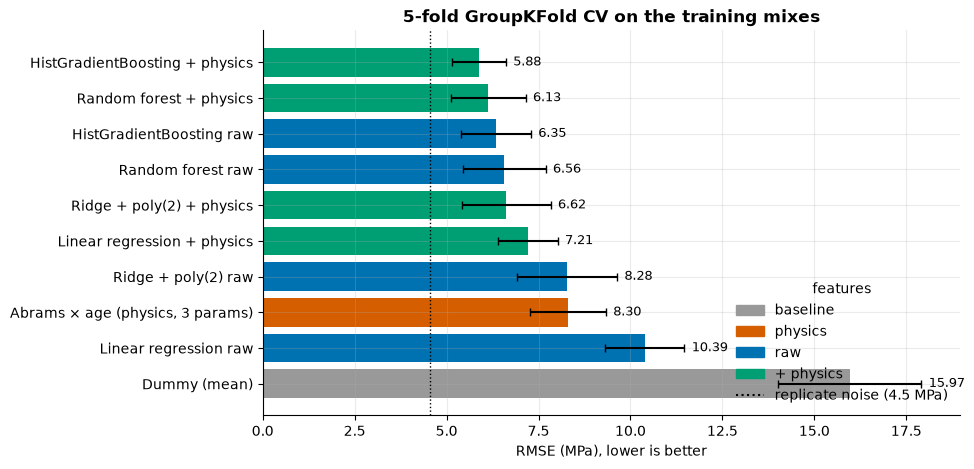

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
order = cv_res.sort_values("CV RMSE", ascending=False)
color_map = {"baseline": "#999999", "physics": PALETTE[3], "raw": PALETTE[0], "+ physics": PALETTE[2]}
ax.barh(order.index, order["CV RMSE"], xerr=order["± (std)"], color=[color_map[t] for t in order.features],
        capsize=3)
for i, v in enumerate(order["CV RMSE"]):
    ax.text(v + order["± (std)"].iloc[i] + 0.2, i, f"{v:.2f}", va="center", fontsize=9)
ax.axvline(noise_sd, color="k", ls=":", lw=1)
ax.legend(handles=[Patch(color=c, label=l) for l, c in color_map.items()]
          + [plt.Line2D([], [], color="k", ls=":", label=f"replicate noise ({noise_sd:.1f} MPa)")],
          loc="lower right", title="features")
ax.set(title="5-fold GroupKFold CV on the training mixes", xlabel="RMSE (MPa), lower is better")
ax.set_xlim(0, order["CV RMSE"].max() + 3)
savefig("model_comparison_cv")
plt.show()

Reading the table:

- The **3-parameter physics model** already cuts the error of the mean-predictor by more than half — domain knowledge
  is a strong baseline.
- **Linear models** gain enormously from physics features (mostly `log_age` and the ratios): they cannot build those
  non-linearities themselves.
- **Tree ensembles** are the best family; physics features still help them under grouped CV, because ratios are hard to
  approximate with axis-aligned splits.

We take **HistGradientBoosting + physics features** forward to tuning.

## 8 · Tune the best model with `RandomizedSearchCV`

Random search over the main capacity/regularisation knobs of gradient boosting, still with grouped folds.

In [17]:
best_pipe = make(HistGradientBoostingRegressor(random_state=RANDOM_STATE), True)
param_dist = {
    "model__learning_rate": loguniform(0.02, 0.3),
    "model__max_iter": randint(150, 800),
    "model__max_leaf_nodes": randint(6, 48),
    "model__min_samples_leaf": randint(3, 30),
    "model__l2_regularization": loguniform(1e-3, 10),
    "model__max_features": uniform(0.4, 0.6),
}
search = RandomizedSearchCV(best_pipe, param_dist, n_iter=30, cv=cv_group, scoring="neg_root_mean_squared_error",
                            random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
search.fit(X_train, y_train, groups=g_train)
print(f"search took {time.time() - t0:.0f}s")
print(f"best CV RMSE: {-search.best_score_:.3f} MPa  (default HGB + physics: {cv_res.loc['HistGradientBoosting + physics', 'CV RMSE']:.3f})")
{k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in search.best_params_.items()}

search took 28s
best CV RMSE: 5.576 MPa  (default HGB + physics: 5.883)


{'l2_regularization': np.float64(0.1256),
 'learning_rate': np.float64(0.0591),
 'max_features': np.float64(0.428),
 'max_iter': 339,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 7}

## 9 · Final evaluation — once — on the test set

`RandomizedSearchCV` refits the best configuration on all training data. Now, and only now, we touch the test mixes.

In [18]:
final = search.best_estimator_
pred = final.predict(X_test)
test_metrics = {"RMSE (MPa)": root_mean_squared_error(y_test, pred), "MAE (MPa)": mean_absolute_error(y_test, pred),
                "R²": r2_score(y_test, pred)}
dummy_rmse = root_mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))
phys_rmse = root_mean_squared_error(y_test, phys_model.predict(X_test))
print(f"test RMSE of mean-predictor: {dummy_rmse:.2f} MPa, physics model: {phys_rmse:.2f} MPa")
pd.Series(test_metrics).round(3)

test RMSE of mean-predictor: 17.81 MPa, physics model: 8.87 MPa


RMSE (MPa)    5.557
MAE (MPa)     3.859
R²            0.903
dtype: float64

### Uncertainty of the test RMSE: a cluster bootstrap

205 test rows is not a lot. We resample **mixes** (not rows — rows of one mix are correlated) with replacement,
recompute the RMSE, and take the 2.5 / 97.5 % percentiles.

In [19]:
test_df = pd.DataFrame({"y": y_test.to_numpy(), "p": pred, "g": g_test.to_numpy()})
mix_ids = test_df.g.unique()
by_mix = {g: grp for g, grp in test_df.groupby("g")}
boot = []
for _ in range(2000):
    sample = pd.concat([by_mix[g] for g in rng.choice(mix_ids, size=len(mix_ids), replace=True)])
    boot.append(root_mean_squared_error(sample.y, sample.p))
boot = np.array(boot)
ci = np.percentile(boot, [2.5, 97.5])
print(f"test RMSE = {test_metrics['RMSE (MPa)']:.2f} MPa, 95% cluster-bootstrap CI [{ci[0]:.2f}, {ci[1]:.2f}]")

test RMSE = 5.56 MPa, 95% cluster-bootstrap CI [4.55, 6.70]


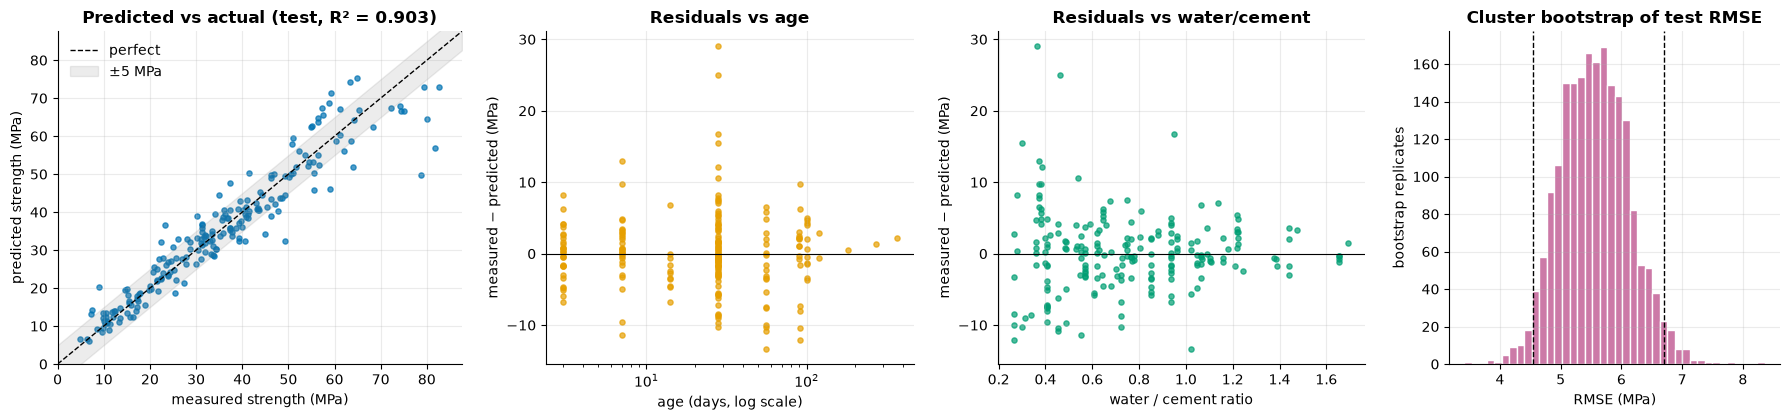

residual by age band (MPa):
           count  mean
age                   
(0, 7]        58  3.01
(7, 28]       95  4.26
(28, 90]      29  4.06
(90, 365]     23  4.09


In [20]:
resid = y_test.to_numpy() - pred
wc_test = (X_test.water / X_test.cement).to_numpy()
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3), gridspec_kw={"width_ratios": [1.1, 1, 1, 0.9]})
axes[0].scatter(y_test, pred, s=14, alpha=0.7, color=PALETTE[0])
lim = [0, max(y_test.max(), pred.max()) + 5]
axes[0].plot(lim, lim, "k--", lw=1, label="perfect")
axes[0].fill_between(lim, np.array(lim) - 5, np.array(lim) + 5, color="grey", alpha=0.15, label="±5 MPa")
axes[0].set(title=f"Predicted vs actual (test, R² = {test_metrics['R²']:.3f})", xlabel="measured strength (MPa)",
            ylabel="predicted strength (MPa)", xlim=lim, ylim=lim)
axes[0].legend(loc="upper left")
axes[1].scatter(X_test.age, resid, s=14, alpha=0.7, color=PALETTE[1])
axes[1].set_xscale("log")
axes[1].set(title="Residuals vs age", xlabel="age (days, log scale)", ylabel="measured − predicted (MPa)")
axes[2].scatter(wc_test, resid, s=14, alpha=0.7, color=PALETTE[2])
axes[2].set(title="Residuals vs water/cement", xlabel="water / cement ratio", ylabel="measured − predicted (MPa)")
for ax in axes[1:3]:
    ax.axhline(0, color="k", lw=0.8)
axes[3].hist(boot, bins=40, color=PALETTE[4], edgecolor="white")
for v in ci:
    axes[3].axvline(v, color="k", ls="--", lw=1)
axes[3].set(title="Cluster bootstrap of test RMSE", xlabel="RMSE (MPa)", ylabel="bootstrap replicates")
fig.tight_layout()
savefig("test_evaluation")
plt.show()

print("residual by age band (MPa):")
print(pd.DataFrame({"age": pd.cut(X_test.age, [0, 7, 28, 90, 365]), "abs_resid": np.abs(resid)})
      .groupby("age", observed=True).abs_resid.agg(["count", "mean"]).round(2))

## 10 · Interpretability — does the model agree with physics?

### Permutation importance on the test set (raw inputs)

We permute the **raw** recipe columns; derived features are recomputed inside the pipeline, so permuting `water`
also scrambles `w_c` and `w_b` — the importance is for the ingredient as a whole.

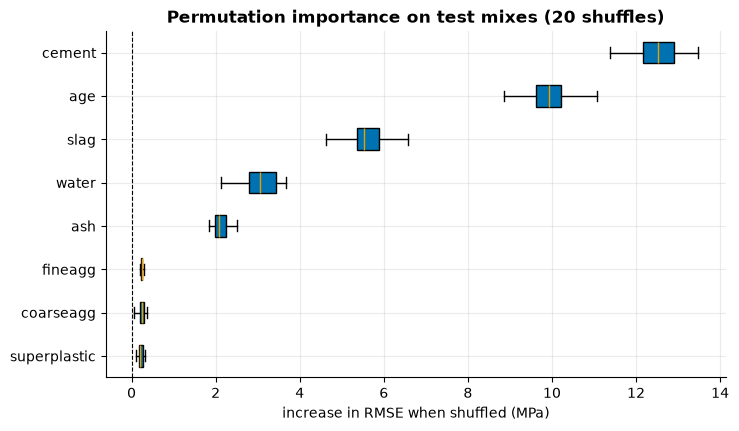

,Δ RMSE (MPa)
cement,12.54
age,9.98
slag,5.55
water,3.08
ash,2.12
fineagg,0.25
coarseagg,0.23
superplastic,0.21


In [21]:
pi = permutation_importance(final, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
order_pi = np.argsort(pi.importances_mean)
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(pi.importances[order_pi].T, orientation="horizontal", patch_artist=True,
                tick_labels=X_test.columns[order_pi], showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor(PALETTE[0])
ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set(title="Permutation importance on test mixes (20 shuffles)", xlabel="increase in RMSE when shuffled (MPa)")
savefig("permutation_importance")
plt.show()
pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False).round(2).to_frame("Δ RMSE (MPa)")

### Partial dependence: age and water–cement ratio

Physics predicts: strength **increases and flattens** with age (concave), and **decreases** with $w/c$.

- **Age** is a raw input, so we compute the PDP through the full pipeline (the transformer recomputes `log_age`).
- $w/c$ is a derived feature. We change it the way an engineer would — **keep the cement, change the water**
  (`water = w/c × cement`) — and average predictions over the training mixes, keeping only rows where the resulting
  water content stays inside the observed range (so we don't ask about impossible mixes).

In [22]:
ages = np.array([1, 3, 7, 14, 28, 56, 90, 120, 180, 270, 365], dtype=float)
pd_age = partial_dependence(final, X_train, ["age"], custom_values={"age": ages}, kind="average", method="brute")
pd_age = pd_age["average"][0]

wc_grid = np.round(np.arange(0.30, 0.91, 0.05), 2)
w_lo, w_hi = X_train.water.min(), X_train.water.max()
pd_wc, n_valid = [], []
for v in wc_grid:
    Xv = X_train.copy()
    Xv["water"] = v * Xv["cement"]
    ok = Xv["water"].between(w_lo, w_hi)
    pd_wc.append(final.predict(Xv[ok]).mean())
    n_valid.append(int(ok.sum()))
pd_wc = np.array(pd_wc)

# Abrams curve at 28 days for comparison (w/c version)
A_wc, B_wc = fits.loc["w_c", ["A (MPa)", "B"]]
checks = {
    "age: monotone increasing": bool(np.all(np.diff(pd_age) > -0.5)),
    "age: concave (gain 1→28 d vs 28→365 d)": f"{pd_age[4] - pd_age[0]:.1f} vs {pd_age[-1] - pd_age[4]:.1f} MPa",
    "w/c: monotone decreasing": bool(np.all(np.diff(pd_wc) < 0.5)),
    "w/c: change 0.30 → 0.90": f"{pd_wc[0]:.1f} → {pd_wc[-1]:.1f} MPa",
}
pd.Series(checks, name="physics check")

age: monotone increasing                              True
age: concave (gain 1→28 d vs 28→365 d)    20.0 vs 11.9 MPa
w/c: monotone decreasing                              True
w/c: change 0.30 → 0.90                    58.0 → 29.8 MPa
Name: physics check, dtype: object

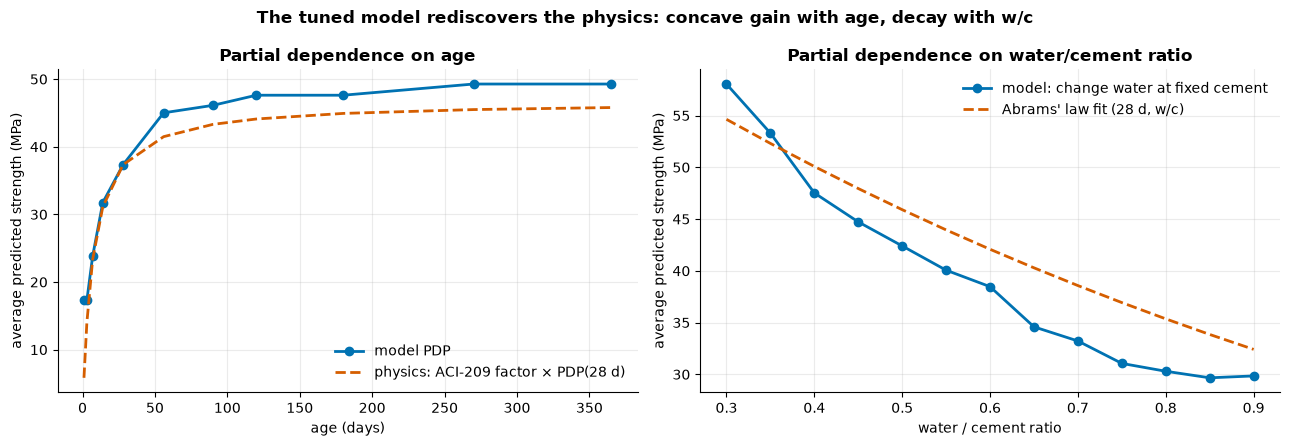

rows averaged per w/c grid value: {np.float64(0.3): 93, np.float64(0.35): 183, np.float64(0.4): 292, np.float64(0.45): 394, np.float64(0.5): 442, np.float64(0.55): 469, np.float64(0.6): 488, np.float64(0.65): 495, np.float64(0.7): 468, np.float64(0.75): 455, np.float64(0.8): 447, np.float64(0.85): 434, np.float64(0.9): 388}


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ages, pd_age, "o-", color=PALETTE[0], lw=2, label="model PDP")
g28 = pd_age[4]
axes[0].plot(ages, g28 * ages / (28 * (1 - b_) + b_ * ages), "--", color=PALETTE[3], lw=2,
             label="physics: ACI-209 factor × PDP(28 d)")
axes[0].set(title="Partial dependence on age", xlabel="age (days)", ylabel="average predicted strength (MPa)")
axes[0].legend(loc="lower right")
axes[1].plot(wc_grid, pd_wc, "o-", color=PALETTE[0], lw=2, label="model: change water at fixed cement")
axes[1].plot(wc_grid, abrams(wc_grid, A_wc, B_wc), "--", color=PALETTE[3], lw=2, label="Abrams' law fit (28 d, w/c)")
axes[1].set(title="Partial dependence on water/cement ratio", xlabel="water / cement ratio",
            ylabel="average predicted strength (MPa)")
axes[1].legend(loc="upper right")
fig.suptitle("The tuned model rediscovers the physics: concave gain with age, decay with w/c", fontweight="bold")
fig.tight_layout()
savefig("pdp_physics_check")
plt.show()
print("rows averaged per w/c grid value:", dict(zip(wc_grid, n_valid)))

Both curves have the shapes physics predicts, although nothing in the model forces them: gradient boosting learned
them from 800 lab tests.

- **Age:** steep gain up to 28 days, then flattening. The model keeps gaining a little more after 56 days than the
  ACI-type factor — slag and fly ash react slowly and keep adding strength for months. At 1 day the model predicts
  ~17 MPa where physics says ~6: there are only 2 one-day tests, and a tree model simply repeats its 3-day value —
  a reminder that trees cannot extrapolate.
- **w/c:** monotone decrease, somewhat steeper than the 28-day Abrams fit (the PDP averages over all ages and mixes,
  and part of the water effect in the Abrams fit is absorbed by other ingredients). Above w/c ≈ 0.8 the curve flattens:
  few data, trees go constant.

If the curves had come out non-monotone, `HistGradientBoostingRegressor(monotonic_cst=...)` could enforce the physics.

## 11 · Save the pipeline, load it back, predict a new mix

In [24]:
model_dir = Path("model")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "concrete_strength_hgb.joblib"
joblib.dump(final, model_path)

train_ranges = X_train.agg(["min", "max"]).T
train_ranges.loc["w_c"] = [tr.w_c.min(), tr.w_c.max()]
train_ranges.loc["w_b"] = [tr.w_b.min(), tr.w_b.max()]
meta = {
    "model": "HistGradientBoostingRegressor + physics features (FunctionTransformer)",
    "sklearn_version": sklearn.__version__,
    "inputs": components + ["age"],
    "units": {"components": "kg/m^3", "age": "days", "target": "MPa"},
    "best_params": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in search.best_params_.items()},
    "cv_rmse_mpa": round(-search.best_score_, 3),
    "test_metrics": {k: round(v, 3) for k, v in test_metrics.items()},
    "test_rmse_95ci_mpa": [round(ci[0], 3), round(ci[1], 3)],
    "training_ranges": {k: [round(a, 3), round(b, 3)] for k, (a, b) in train_ranges.iterrows()},
}
(model_dir / "model_card.json").write_text(json.dumps(meta, indent=2))
print(f"saved {model_path} ({model_path.stat().st_size / 1024:.0f} kB) and model_card.json")

saved model/concrete_strength_hgb.joblib (369 kB) and model_card.json


> **Pickling caveat:** `joblib` stores `add_physics_features` *by reference* (`__main__.add_physics_features`).
> Loading works in this notebook; in a separate service the function must be importable — put it in a module
> (e.g. `concrete_features.py`) and import it before `joblib.load`.

In [25]:
loaded = joblib.load(model_path)
new_mixes = pd.DataFrame([
    # a plain C30-type mix, w/c = 0.50
    dict(cement=350, slag=0, ash=0, water=175, superplastic=0, coarseagg=1050, fineagg=780, age=28),
    # same binder content, 40 % slag replacement + superplasticizer, w/b = 0.40
    dict(cement=210, slag=140, ash=0, water=140, superplastic=6, coarseagg=1050, fineagg=830, age=28),
    # outside the training domain: 2-year-old, very low w/c
    dict(cement=520, slag=0, ash=0, water=125, superplastic=15, coarseagg=1000, fineagg=720, age=730),
], dtype=float)
print("loaded model gives identical test predictions:", np.allclose(loaded.predict(X_test), pred))


def domain_warnings(X):
    feats = add_physics_features(X)
    out = []
    for i, row in feats.iterrows():
        bad = [f"{c}={row[c]:.3g} ∉ [{train_ranges.loc[c, 'min']:.3g}, {train_ranges.loc[c, 'max']:.3g}]"
               for c in train_ranges.index if not (train_ranges.loc[c, "min"] <= row[c] <= train_ranges.loc[c, "max"])]
        out.append("; ".join(bad) if bad else "ok")
    return out


report = new_mixes.assign(w_c=new_mixes.water / new_mixes.cement,
                          predicted_MPa=loaded.predict(new_mixes).round(1),
                          physics_MPa=phys_model.predict(new_mixes).round(1),
                          domain_check=domain_warnings(new_mixes))
report[["cement", "slag", "water", "superplastic", "age", "w_c", "predicted_MPa", "physics_MPa", "domain_check"]]

loaded model gives identical test predictions: True


,cement,slag,water,superplastic,age,w_c,predicted_MPa,physics_MPa,domain_check
0,350.0,0.0,175.0,0.0,28.0,0.500000,34.0,34.8,ok
1,210.0,140.0,140.0,6.0,28.0,0.666667,43.5,44.4,ok
2,520.0,0.0,125.0,15.0,730.0,0.240385,66.9,80.8,"age=730 ∉ [1, 365]; w_c=0.24 ∉ [0.28, 1.88]"


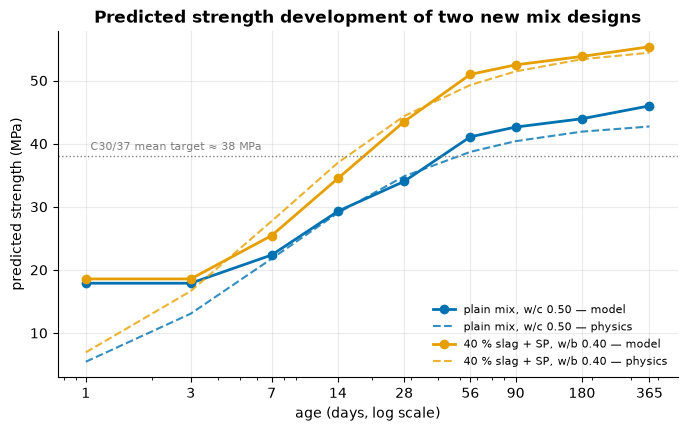

In [26]:
curve_ages = np.array([1, 3, 7, 14, 28, 56, 90, 180, 365], dtype=float)
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, label in enumerate(["plain mix, w/c 0.50", "40 % slag + SP, w/b 0.40"]):
    mix = pd.concat([new_mixes.iloc[[i]]] * len(curve_ages), ignore_index=True).assign(age=curve_ages)
    ax.plot(curve_ages, loaded.predict(mix), "o-", color=PALETTE[i], lw=2, label=f"{label} — model")
    ax.plot(curve_ages, phys_model.predict(mix), "--", color=PALETTE[i], lw=1.5, alpha=0.8, label=f"{label} — physics")
ax.axhline(38, color="grey", ls=":", lw=1)
ax.text(1.05, 39, "C30/37 mean target ≈ 38 MPa", fontsize=8, color="grey")
ax.set_xscale("log")
ax.set_xticks(curve_ages, [str(int(a)) for a in curve_ages])
ax.set(title="Predicted strength development of two new mix designs", xlabel="age (days, log scale)",
       ylabel="predicted strength (MPa)")
ax.legend(fontsize=8, loc="lower right")
savefig("new_mix_prediction")
plt.show()

The slag + superplasticizer mix, thanks to its much lower water–binder ratio, is predicted stronger at every age
and is the one that would reach a C30/37 target at 28 days. Model and physics curves agree well between 7 and
365 days. Before 3 days they diverge: the model is flat between 1 and 3 days because there are only two
1-day tests in the whole dataset — trees output a constant where data are missing. Treat very-early-age
predictions (and anything outside the training ranges) with suspicion.

In [27]:
print(f"Total notebook runtime: {time.time() - T0:.0f}s")

Total notebook runtime: 48s


## 12 · Model card

| | |
|---|---|
| **Model** | `HistGradientBoostingRegressor` inside a `Pipeline` with physics features (w/c, w/b, log age, binder, aggregate/binder, SP/binder, SCM fraction) |
| **Intended use** | Screening / ranking candidate mix designs before trial batches; estimating strength development curves |
| **Not for** | Structural acceptance or compliance (replace with standard cylinder/cube tests); safety-critical decisions without testing |
| **Data** | Yeh (1998), UCI Concrete Compressive Strength, 1030 lab tests (1005 after removing 25 duplicates), 427 mixes, CC BY 4.0 |
| **Evaluation** | Grouped by mix; test set = 20 % of mixes never seen in training; see RMSE/MAE/R² and bootstrap CI above |
| **Inputs** | 7 ingredients in kg/m³ + age in days (1–365) |
| **Limits / extrapolation** | Only trained within the ranges in `model/model_card.json` (e.g. age ≤ 365 d, w/c ≈ 0.27–1.9). No information on cement type, aggregate type/size, curing temperature/humidity, air content, specimen shape. Tree models predict a **constant** outside the training range — they cannot extrapolate trends. |
| **Known behaviour** | Mean absolute error ≈ 3 MPa for ages ≤ 7 d and ≈ 4 MPa later; a few 28-day tests are under-predicted by 15–29 MPa; predictions at 1 day are unreliable (only 2 training tests) |
| **Ethics / safety** | An over-prediction of strength is the dangerous direction; use a safety margin (e.g. subtract ~1.64 × RMSE for a 5 % lower bound) |

## Key takeaways

- **Frame** the metric in engineering units and compare it to the natural noise (replicate scatter) and to strength-class spacing.
- **Audit with physics**: mass balance, impossible values, duplicates and replicates tell you what the data really are.
- **Grouped data need grouped splits.** A random split leaked mixes across folds and under-stated RMSE by ≈ 1 MPa.
- **Domain knowledge is a strong model**: a 3-parameter Abrams × age law halves the baseline error; as features, the
  same ratios make linear models competitive and improve tree ensembles.
- Put feature engineering **inside the pipeline** (`FunctionTransformer`) so CV, test and production compute it identically.
- Evaluate **once** on the test set, report an **uncertainty** (cluster bootstrap), and check that interpretations
  (PDPs) agree with physics before trusting the model.

## Exercises

1. **Monotone constraints.** Refit the final model with `monotonic_cst` forcing strength to increase with `log_age`,
   `cement` and decrease with `w_c`, `w_b`, `water`. Does test RMSE change? *Hint:* `monotonic_cst` accepts a dict
   `{feature_name: +1/-1}` when the input has feature names — use `set_output(transform="pandas")` or check the pipeline's
   output columns.
2. **28-day model only.** Restrict to 28-day tests, repeat the model comparison and compare with Abrams' law alone.
   *Hint:* with `age` constant, which physics features still matter?
3. **Prediction intervals.** Fit `HistGradientBoostingRegressor(loss="quantile", quantile=0.05)` and `0.95` and check the
   empirical coverage on the test set. *Hint:* coverage = mean of `(y >= lo) & (y <= hi)`.
4. **How much data?** Plot a learning curve (grouped CV RMSE vs number of training mixes). Would collecting more mixes help?
   *Hint:* `sklearn.model_selection.learning_curve(..., groups=g_train, cv=cv_group)`.
5. **Leakage, quantified.** Repeat the model comparison with `KFold` instead of `GroupKFold`. Which models profit most
   from the leak, and why? *Hint:* flexible models can memorise a mix's recipe.